# Forecasting Inflation
### **Adam Mendoza**

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from pmdarima.arima import auto_arima
from xgboost import XGBRegressor, plot_importance


In [126]:
bsp_cpi = pd.read_csv('..//data//bsp_cpibase2018_dataset.csv')
usd_php = pd.read_csv('..//data//usd_to_php.csv')
unemployment = pd.read_csv('..//data//psa_unemployment_rate.csv')
crude = pd.read_csv('..//data//global_dubai_crude.csv')

In [127]:
bsp_cpi['Date'] = pd.to_datetime(bsp_cpi['Year'].astype(str) + ' ' + bsp_cpi['Month'] + ' 1')
bsp_cpi.rename(columns={'All Items': 'CPI'}, inplace=True)
bsp_cpi = bsp_cpi[['Date', 'CPI']]
bsp_cpi.set_index('Date', inplace = True)

## **Preamble**
The change in the general level of prices in an economy is quantified through the **inflation rate**. In practice, this is often measured by determining how the **consumer price index** of a typical basket of goods vary in a span of a year. In other words

\begin{align}
I_{\mathrm{YoY}}&=\frac{\mathrm{CPI}_{t}-\mathrm{CPI}_{t-12}}{\mathrm{CPI}_{t-12}}*100\%.
\end{align}

In [128]:
inflation_rate = bsp_cpi['CPI'].pct_change(12) * 100
bsp_cpi['InflationRate'] = inflation_rate
full_inf = bsp_cpi.dropna()

full_inf.head()

,CPI,InflationRate
Date,,
1958-01-01,0.891176,6.25000
1958-02-01,0.891176,6.25000
1958-03-01,0.884623,5.46875
1958-04-01,0.884623,5.46875
1958-05-01,0.891176,6.25000


In [129]:
# USD/PHP
usd_php['Year'] = usd_php['Period'].ffill()
usd_php['Date'] = pd.to_datetime(usd_php['Year'].astype(int).astype(str) + ' ' + usd_php['Unnamed: 1'] + ' 1')
usd_php = usd_php[['Date', 'Average']].rename(columns={'Average': 'USD_PHP'})

# Unemployment
unemployment['Date'] = pd.to_datetime(unemployment['Year'].astype(str) + ' ' + unemployment['Monthly/Quarterly'] + ' 1')
unemployment['Unemployment Rate'] = pd.to_numeric(unemployment['Unemployment Rate'], errors='coerce')
unemployment = unemployment[['Date', 'Unemployment Rate']].rename(columns={'Unemployment Rate': 'UnemploymentRate'}).sort_values('Date')
unemployment['UnemploymentRate'] = unemployment['UnemploymentRate'].interpolate(method='pad', limit_area='inside')

# Crude oil
crude['Date'] = pd.to_datetime(crude['observation_date'])
crude = crude[['Date', 'POILDUBUSDM']].rename(columns={'POILDUBUSDM': 'DubaiCrude'})

# Merge all
inf_data = full_inf.merge(usd_php, on='Date', how='inner').merge(unemployment, on='Date', how='inner').merge(crude, on='Date', how='inner').sort_values('Date').reset_index(drop=True)
inf_data.set_index("Date", inplace = True)

inf_data.head()

C:\Users\PC\AppData\Local\Temp/ipykernel_14196/1389751579.py:10: FutureWarning: Series.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  unemployment['UnemploymentRate'] = unemployment['UnemploymentRate'].interpolate(method='pad', limit_area='inside')


,CPI,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude
Date,,,,,
2005-01-01,60.678618,7.300116,55.766190,11.40,38.320000
2005-02-01,60.809673,7.283237,54.812842,11.40,39.673000
2005-03-01,60.940728,7.142857,54.440200,11.40,46.075652
2005-04-01,61.202839,7.233065,54.491762,8.28,47.096190
2005-05-01,61.530477,7.314286,54.341095,8.28,45.074091


Check if there are no missing months

In [130]:
full_inf = full_inf['InflationRate']
inf = inf_data['InflationRate']
freq = pd.infer_freq(inf.index.sort_values())
print(freq)

MS


Plot the data

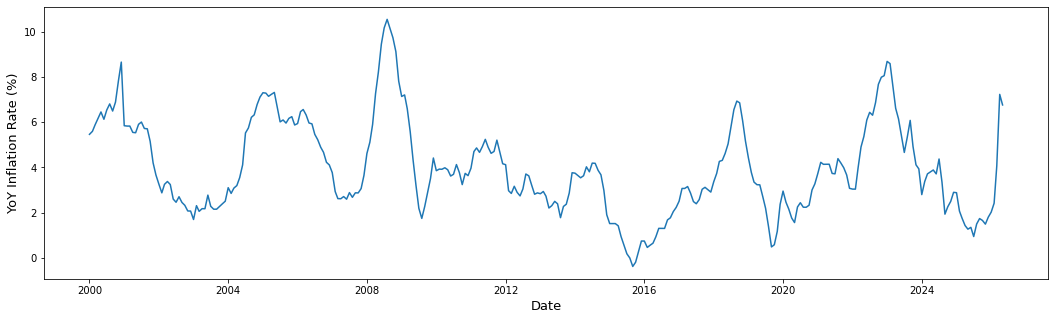

In [131]:
plt.figure(figsize=(18, 5))
plt.plot(full_inf.loc['2000':])
plt.xlabel('Date', fontsize = 13)
plt.ylabel('YoY Inflation Rate (%)', fontsize = 13)
plt.show()

The plot of the year-on-year inflation rate, which we will simply call *inflation* henceforth, exhibits periods of inflation and disinflation (inflation rate goes down). However, there exists persistent sustained increase which can be explained by local and international events. 

**2004 - 2006** - Global oil price surge and expanded VAT law 

**2008 - 2009** - Global oil price surge and global food price crisis, the former being one of the causes. The consequent sharp dip can be explained by global 

**2016 - 2019** - *Build, Build, Build* leading to an increase in government spending and therefore, demand, amplified by *TRAIN Law* signed in Dec 2019. 

**2020 - 2024** - COVID-19 Pandemic, disrupting supply chains. The steady rise can be explained by decreasing production but increasing demands, resulting into overheat. 

In the current period, we are observing a dramatic rise of inflation due to the ongoing Iran war. In particular, the restrictions in the Strait of Hormuz constricts the global oil supply, leading to another global oil price surge. 

# I. Classical forecast: SARIMA and SARIMAX


First, we will use the full inflation data and check for stationarity. We use the Augmented Dickey-Fuller test. The null hypothesis, $H_0$, is that the series is **non-stationary**. We reject it when ADF statistic $<$ critical value.

In [132]:
adfuller(full_inf)

(-4.405822176856041,
 0.00028986881500239845,
 21,
 799,
 {'1%': -3.4385608049885876,
  '5%': -2.865164107438179,
  '10%': -2.5686998068142124},
 2559.2892887467983)

The ADF test statistic is `-4.4`. Since the test statistic is less than the critical values at $1\%$, $5\%$, and $10\%$, we reject the null hypothesis at all levels. In the Kwiatkowski-Phillips-Schmidt-Shin (KPSS), however, the null hypothesis, $H_0$, is that the series is **stationary**. We reject it when KPSS statistic $>$ critical value.

In [133]:
kpss(full_inf)

C:\Users\PC\AppData\Local\Temp/ipykernel_14196/1252803741.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss(full_inf)


(0.7668438377492122,
 0.01,
 17,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

The KPSS test statistic is `0.767`. Since the test statistic is greater than the critical values at $1\%$, $5\%$, and $10\%$, we reject the null hypothesis at all levels. These two tests taken together means that stationarity is inconclusive.

In [134]:
months_inc = 24

inf_train = full_inf[:-months_inc]
inf_test = full_inf[-months_inc:]

In [135]:
sarima_model = auto_arima(inf_train, seasonal=True, m=12) 
print(sarima_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  797
Model:             SARIMAX(1, 1, 2)x(0, 0, [1], 12)   Log Likelihood               -1181.061
Date:                              Sun, 14 Jun 2026   AIC                           2372.122
Time:                                      16:18:11   BIC                           2395.520
Sample:                                  01-01-1958   HQIC                          2381.113
                                       - 05-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8824      0.022     40.104      0.000       0.839       0.926
ma.L1         -0.53

We compare the SARIMA forecast with naive forecasts.

In [136]:
sarima_forecast = pd.Series(sarima_model.predict(n_periods=len(inf_test)), index=inf_test.index)
naive_forecast = pd.Series(np.repeat(inf_train.iloc[-1], len(inf_test)), index=inf_test.index)
seasonal_naive_forecast = inf.shift(12).loc[inf_test.index]

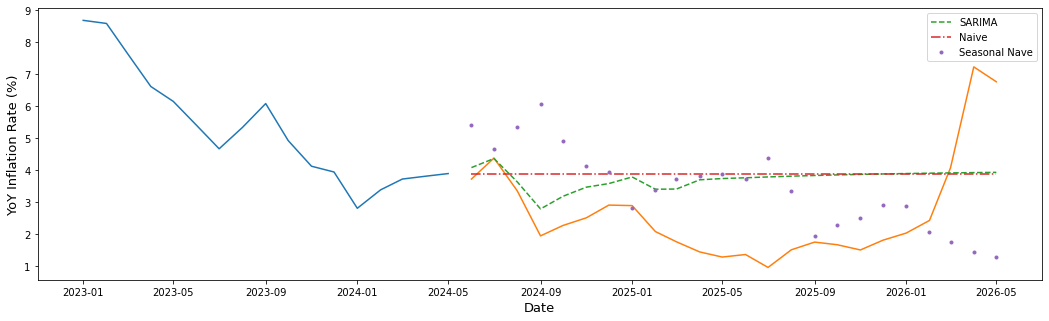

In [137]:
start_date = '2023-01-01'

plt.figure(figsize=(18, 5))
plt.plot(inf_train.loc[start_date:])
plt.plot(inf_test.loc[start_date:])
plt.plot(sarima_forecast.loc[start_date:], '--', label = 'SARIMA')
plt.plot(naive_forecast.loc[start_date:], '-.', label = 'Naive')
plt.plot(seasonal_naive_forecast.loc[start_date:], '.', label = 'Seasonal Nave')

plt.xlabel('Date', fontsize = 13)
plt.ylabel('YoY Inflation Rate (%)', fontsize = 13)
plt.legend()
plt.show()

In [138]:
comp_forecasts = [sarima_forecast, naive_forecast, seasonal_naive_forecast]
rmse_list = []
for forecast in comp_forecasts:
    mae = mean_absolute_error(inf_test, forecast)
    rmse = np.sqrt(mean_squared_error(inf_test, forecast))
    rmse_list.append(rmse)

print('The RMSE for SARIMA is {:.2f}'.format(rmse_list[0]))
print('The RMSE for Naive is {:.2f}'.format(rmse_list[1]))
print('The RMSE for Seasonal Naive is {:.2f}'.format(rmse_list[2]))

The RMSE for SARIMA is 1.85
The RMSE for Naive is 2.01
The RMSE for Seasonal Naive is 2.47


In [139]:
horizons = [1, 2, 6, 12, 24]

results = []

for h in horizons:
    inf_train = full_inf.iloc[:-h]
    inf_test = full_inf.iloc[-h:]

    sarima_model = auto_arima(inf_train, seasonal=True, m=12, suppress_warnings=True)

    sarima_forecast = pd.Series(sarima_model.predict(n_periods=h), index=inf_test.index)

    naive_forecast = pd.Series(np.repeat(inf_train.iloc[-1], h), index=inf_test.index)

    seasonal_naive_forecast = full_inf.shift(12).loc[inf_test.index]

    sarima_rmse = np.sqrt(mean_squared_error(inf_test, sarima_forecast))
    naive_rmse = np.sqrt(mean_squared_error(inf_test, naive_forecast))
    seasonal_naive_rmse = np.sqrt(mean_squared_error(inf_test, seasonal_naive_forecast))

    results.append({
        "Forecast Horizon": h,
        "SARIMA RMSE": sarima_rmse,
        "Naive RMSE": naive_rmse,
        "Seasonal Naive RMSE": seasonal_naive_rmse
    })

In [140]:
rmse_table = pd.DataFrame(results)
rmse_table

,Forecast Horizon,SARIMA RMSE,Naive RMSE,Seasonal Naive RMSE
0,1,1.657588,0.466016,5.487121
1,2,1.760592,2.934423,5.642010
2,6,2.929000,3.376615,3.442484
3,12,2.052118,2.518216,2.787378
4,24,1.852536,2.011048,2.466339


SARIMA outperforms naive forecasts for 2 to 12 month horizons but fails for 24 month horizon. We will now deploy for a forecast for the next six months.

In [141]:
sarima_model_final = auto_arima(full_inf, seasonal=True, m=12, suppress_warnings=True)
sarima_forecast = pd.Series(sarima_model_final.predict(n_periods=6))
sarima_forecast

2026-06-01    7.036636
2026-07-01    7.390334
2026-08-01    7.378207
2026-09-01    7.795006
2026-10-01    8.106122
2026-11-01    8.447115
Freq: MS, dtype: float64

The forecasted June inflation is $7\%$ and will steadily increase to $8.45\%$ come November. We now do SARIMAX, where we use exogenous variables such as the USD to PHP exchange rate, unemployment rate, and the price of a barrel of Dubai Crude Oil in USD.

In [142]:
months_inc = 24

exog = inf_data[['USD_PHP', 'UnemploymentRate', 'DubaiCrude']]

inf_train = inf[:-months_inc]
inf_test = inf[-months_inc:]

exog_train = exog[:-months_inc]
exog_test = exog[-months_inc:]

In [143]:
sarimax_model = auto_arima(inf_train, X = exog_train, seasonal=True, m=12) 
print(sarimax_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  233
Model:             SARIMAX(1, 1, 0)x(0, 0, [1], 12)   Log Likelihood                 -78.191
Date:                              Sun, 14 Jun 2026   AIC                            168.382
Time:                                      16:22:25   BIC                            189.062
Sample:                                  01-01-2005   HQIC                           176.722
                                       - 05-01-2024                                         
Covariance Type:                                opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
USD_PHP              0.0163      0.024      0.686      0.493      -0.030       0.063
U

In [144]:
sarimax_forecast = pd.Series(sarimax_model.predict(n_periods=len(inf_test), X=exog_test), index=inf_test.index)
naive_forecast = pd.Series(np.repeat(inf_train.iloc[-1], len(inf_test)), index=inf_test.index)
seasonal_naive_forecast = inf.shift(12).loc[inf_test.index]

In [145]:
comp_forecasts = [sarimax_forecast, naive_forecast, seasonal_naive_forecast]
rmse_list = []
for forecast in comp_forecasts:
    mae = mean_absolute_error(inf_test, forecast)
    rmse = np.sqrt(mean_squared_error(inf_test, forecast))
    rmse_list.append(rmse)

print('The RMSE for SARIMAX is {:.2f}'.format(rmse_list[0]))
print('The RMSE for Naive is {:.2f}'.format(rmse_list[1]))
print('The RMSE for Seasonal Naive is {:.2f}'.format(rmse_list[2]))

The RMSE for SARIMAX is 1.98
The RMSE for Naive is 2.01
The RMSE for Seasonal Naive is 2.47


We got a larger RMSE for SARIMAX than SARIMA. We can owe this from a reduced number of samples due to data availability of exogenous variables. Pure SARIMA has a larger sample size for the inflation rate data and may capture behaviors that are observable on longer terms. We will now forecast.

In [146]:
sarima_usdphp = auto_arima(exog['USD_PHP'], seasonal=True) 
sarima_unemployment = auto_arima(exog['UnemploymentRate'], seasonal=True)
sarima_dubai = auto_arima(exog['DubaiCrude'], seasonal=True)

future_usdphp = pd.Series(sarima_usdphp.predict(n_periods=6), name = exog['USD_PHP'].name)
future_unemployment = pd.Series(sarima_unemployment.predict(n_periods=6), name = exog['UnemploymentRate'].name)
future_dubai = pd.Series(sarima_dubai.predict(n_periods=6), name = exog['DubaiCrude'].name)

future_exog = pd.concat([future_usdphp, future_unemployment, future_dubai], axis = 1)
full_exog = pd.concat([exog, future_exog])

sarima_model_final = auto_arima(inf, X = exog, seasonal=True, m=12, suppress_warnings=True)
sarima_forecast = pd.Series(sarima_model_final.predict(n_periods=6, X = future_exog))
sarima_forecast

2026-06-01    5.995891
2026-07-01    6.045590
2026-08-01    6.033223
2026-09-01    6.307850
2026-10-01    6.293417
2026-11-01    6.351398
Freq: MS, dtype: float64

SARIMAX predicts $6\%$ inflation rate for June, steadily increasing to $6.35\%$ in November.

## II. XGBoost

In [176]:
full_inf = bsp_cpi.dropna().copy()

full_inf["month"] = full_inf.index.month
full_inf["quarter"] = full_inf.index.quarter
full_inf["year"] = full_inf.index.year

full_inf["month_sin"] = np.sin(2 * np.pi * full_inf["month"] / 12)
full_inf["month_cos"] = np.cos(2 * np.pi * full_inf["month"] / 12)

for lag in [1, 2, 3, 6, 12]:
    full_inf[f"inf_lag_{lag}"] = full_inf["InflationRate"].shift(lag)

for lag in [1, 2, 3, 6, 12]:
    full_inf[f"cpi_lag_{lag}"] = full_inf["CPI"].shift(lag)

for window in [3, 6, 12]:
    full_inf[f"inf_roll_mean_{window}"] = full_inf["InflationRate"].shift(1).rolling(window).mean()
    full_inf[f"inf_roll_std_{window}"] = full_inf["InflationRate"].shift(1).rolling(window).std()

full_inf["cpi_mom"] = full_inf["CPI"].pct_change(1) * 100
full_inf["cpi_qoq"] = full_inf["CPI"].pct_change(3) * 100
full_inf["cpi_hy"] = full_inf["CPI"].pct_change(6) * 100

full_inf["target"] = full_inf["InflationRate"].shift(-1)

feature_cols = [
    "month", "quarter", "year",
    "month_sin", "month_cos",
    "inf_lag_1", "inf_lag_2", "inf_lag_3", "inf_lag_6", "inf_lag_12",
    "cpi_lag_1", "cpi_lag_2", "cpi_lag_3", "cpi_lag_6", "cpi_lag_12",
    "inf_roll_mean_3", "inf_roll_mean_6", "inf_roll_mean_12",
    "inf_roll_std_3", "inf_roll_std_6", "inf_roll_std_12",
    "cpi_mom", "cpi_qoq", "cpi_hy"
]

forecast_X = full_inf[feature_cols].iloc[[-1]]

train_df = full_inf.dropna()

X = train_df[feature_cols]
y = train_df["target"]

split_idx = int(len(train_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

The RMSE for XGBoost is 0.695


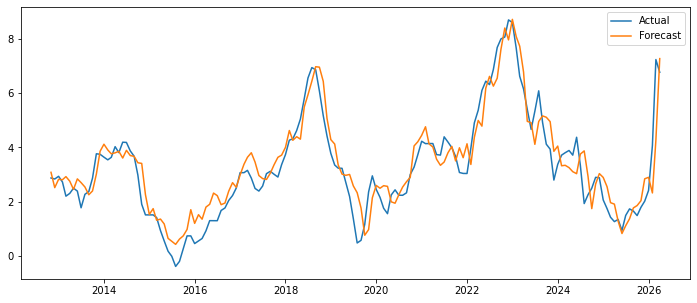

In [177]:
model = XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror", random_state=420)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"The RMSE for XGBoost is {rmse:.3f}")

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Forecast")
plt.legend()
plt.show()


In [178]:
X_full = train_df[feature_cols]
y_full = train_df["target"]

model = XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror", random_state=42)
model.fit(X_full, y_full)
forecast = model.predict(forecast_X)
print(f"June inflation: {forecast[0]:.2f}%")

June inflation: 6.99%
